In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import pandas as pd
import random

from ase import Atoms, units
from ase.io import read, write, Trajectory
from ase import units
from mace.calculators import MACECalculator
from ase.data import chemical_symbols

from tensorpotential.calculator import TPCalculator
from tensorpotential.calculator.foundation_models import grace_fm

import os
import math
# from sklearn.metrics import r2_score
# import seaborn as sns
# from sklearn.metrics import mean_squared_error, root_mean_squared_error

/home/anna/miniconda3/envs/ai-fennel_2/lib/python3.9/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


2025-11-05 09:47:04.028236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762332424.049493 1232767 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762332424.055838 1232767 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762332424.072519 1232767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762332424.072551 1232767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762332424.072553 1232767 computation_placer.cc:177] computation placer alr

In [3]:
experiment = "b_off_small_models"
# os.mkdir(f"{experiment}")

model_path = "../models"
# Load data for different tests
# For torsion profiles
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
data_biaryl = h5py.File("../data/Biaryl-SPICE.hdf5", "r")
# For energies and forces
structures = read("../data/b_off_2.0_all_energies.xyz", ":")
ref_structures = read("../data/b_off_2.0_all_energies.xyz", ":")

In [4]:
calc_grace_small = TPCalculator(
    model=f"{model_path}/2l/b_off_small/seed/1/saved_model/"
)
calc_grace_medium = TPCalculator(
    model=f"{model_path}/2l/b_off_medium/seed/1/saved_model/"
)
# calc_grace_large = TPCalculator(
#     model=f"{model_path}/2l/b_off_large/seed/1/saved_model/"
# )

calc_mace_large = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_large.model", device="cuda"
)
calc_mace_medium = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF24_medium.model", device="cuda"
)
calc_mace_small = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_small.model", device="cuda"
)

/home/anna/miniconda3/envs/ai-fennel_2/lib/python3.9/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


/home/anna/miniconda3/envs/ai-fennel_2/lib/python3.9/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


/home/anna/miniconda3/envs/ai-fennel_2/lib/python3.9/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [5]:
smiles = list(data_tnet.keys())[0]

In [6]:
Z = data_tnet[smiles]["atomic_numbers"][:]
symbols = [chemical_symbols[int(z)] for z in Z]


In [ ]:
torsion_energies_small = []
torsion_energies_medium = []

for i, conf in enumerate(data_tnet[smiles]["conformations"]):
    pos = data_tnet[smiles]["conformations"][i][:] * units.Bohr
    mol = Atoms(symbols=symbols, positions=pos)
    mol.calc = calc_grace_small
    energy = mol.get_potential_energy()
    torsion_energies_small.append(energy)

    mol.calc = calc_grace_medium
    energy = mol.get_potential_energy()
    torsion_energies_medium.append(energy)


I0000 00:00:1762330912.082212 1223998 service.cc:148] XLA service 0x559343aea9e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762330912.082245 1223998 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-11-05 09:21:52.308652: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1762330912.641162 1223998 cuda_dnn.cc:529] Loaded cuDNN version 91301
I0000 00:00:1762330915.793666 1223998 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


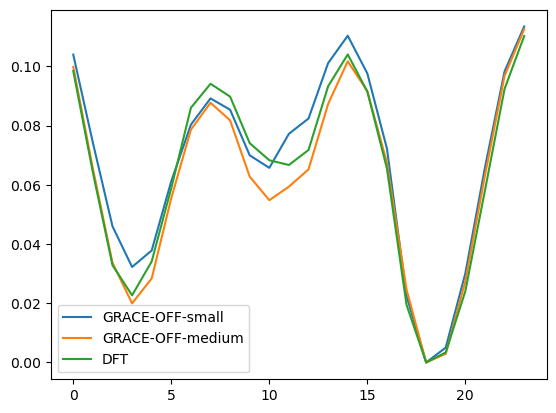

In [8]:
plt.plot(np.asarray(torsion_energies_small) - min(np.asarray(torsion_energies_small)), label="GRACE-OFF-small")
plt.plot(np.asarray(torsion_energies_medium) - min(np.asarray(torsion_energies_medium)), label="GRACE-OFF-medium")
plt.plot(data_tnet[smiles]["dft total energy"][:]* 27.211386245988 - min(data_tnet[smiles]["dft total energy"][:]* 27.211386245988), label="DFT")
plt.legend()

Fläche zwischen den Kurven = 0.137274 (in Energie·Index-Einheiten)


/tmp/ipykernel_1223998/2474034839.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(np.abs(y1 - y2), x)


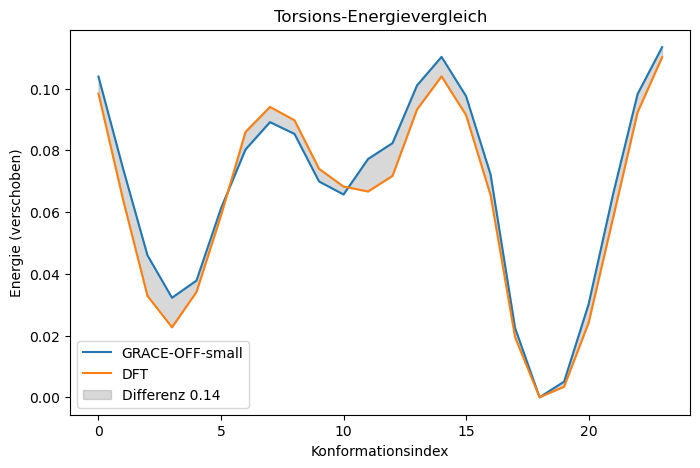

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Beispiel-Daten: n Punkte
x = np.arange(len(torsion_energies_small))

# Deine Kurven (auf gleicher x-Achse)
y1 = np.asarray(torsion_energies_small) - np.min(np.asarray(torsion_energies_small))
y2 = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
y2 = y2 - np.min(y2)

# Berechne Fläche zwischen den Kurven (Integral über |y1 - y2|)
area = np.trapz(np.abs(y1 - y2), x)

# Fläche zwischen den Kurven füllen
plt.figure(figsize=(8,5))
plt.plot(x, y1, label="GRACE-OFF-small")
plt.plot(x, y2, label="DFT")

# Bereich zwischen den Kurven füllen (komplett farbig)
plt.fill_between(x, y1, y2, color='gray', alpha=0.3, label=f"Differenz {round(area,2)}")

# Alternativ: strichlierte Fläche statt Füllung:
# plt.fill_between(x, y1, y2, color='none', hatch='//', edgecolor='gray', linewidth=0.0, alpha=0.5)

plt.legend()
plt.xlabel("Konformationsindex")
plt.ylabel("Energie (verschoben)")
plt.title("Torsions-Energievergleich")



print(f"Fläche zwischen den Kurven = {area:.6f} (in Energie·Index-Einheiten)")
plt.show()


In [19]:
from tqdm import tqdm
import numpy as np
from ase import Atoms
from ase.data import chemical_symbols
from ase import units

def get_area_error_grace(small: bool, medium: bool, large: bool):
    error_trapez_grace_small = []
    error_trapez_grace_medium = []
    error_trapez_grace_large = []

    # tqdm über Moleküle
    for smiles in tqdm(data_tnet.keys(), desc="Berechne Fehlerflächen", unit="mol", ncols=80):
        Z = data_tnet[smiles]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]

        torsion_energies_small = []
        torsion_energies_medium = []
        torsion_energies_large = []

        # DFT-Referenzkurve
        dft_energy = np.asarray(data_tnet[smiles]["dft total energy"][:]) * 27.211386245988

        # Schleife über Konformationen
        for conf in data_tnet[smiles]["conformations"]:
            pos = conf[:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            if small:
                mol.calc = calc_grace_small
                torsion_energies_small.append(mol.get_potential_energy())

            if medium:
                mol.calc = calc_grace_medium
                torsion_energies_medium.append(mol.get_potential_energy())

            if large:
                mol.calc = calc_grace_large
                torsion_energies_large.append(mol.get_potential_energy())

        # Nach der Konformationsschleife: x-Achse erst jetzt definieren
        x = np.arange(len(dft_energy))

        if small and torsion_energies_small:
            grace_small_error = (np.array(torsion_energies_small) - np.min(torsion_energies_small)) - (dft_energy - np.min(dft_energy))
            area_small = np.trapezoid(np.abs(grace_small_error), x)
            error_trapez_grace_small.append(area_small)

        if medium and torsion_energies_medium:
            grace_medium_error = (np.array(torsion_energies_medium) - np.min(torsion_energies_medium)) - (dft_energy - np.min(dft_energy))
            area_medium = np.trapezoid(np.abs(grace_medium_error), x)
            error_trapez_grace_medium.append(area_medium)

        if large and torsion_energies_large:
            grace_large_error = (np.array(torsion_energies_large) - np.min(torsion_energies_large)) - (dft_energy - np.min(dft_energy))
            area_large = np.trapezoid(np.abs(grace_large_error), x)
            error_trapez_grace_large.append(area_large)

    return error_trapez_grace_small, error_trapez_grace_medium, error_trapez_grace_large


In [22]:
from tqdm import tqdm
import numpy as np
from ase import Atoms
from ase.data import chemical_symbols
from ase import units

def get_area_error_mace(small: bool, medium: bool, large: bool):
    error_trapez_mace_small = []
    error_trapez_mace_medium = []
    error_trapez_mace_large = []

    # tqdm über Moleküle
    for smiles in tqdm(data_tnet.keys(), desc="Berechne Fehlerflächen", unit="mol", ncols=80):
        Z = data_tnet[smiles]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]

        torsion_energies_small = []
        torsion_energies_medium = []
        torsion_energies_large = []

        # DFT-Referenzkurve
        dft_energy = np.asarray(data_tnet[smiles]["dft total energy"][:]) * 27.211386245988

        # Schleife über Konformationen
        for conf in data_tnet[smiles]["conformations"]:
            pos = conf[:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            if small:
                mol.calc = calc_mace_small
                torsion_energies_small.append(mol.get_potential_energy())

            if medium:
                mol.calc = calc_mace_medium
                torsion_energies_medium.append(mol.get_potential_energy())

            if large:
                mol.calc = calc_mace_large
                torsion_energies_large.append(mol.get_potential_energy())

        # Nach der Konformationsschleife: x-Achse erst jetzt definieren
        x = np.arange(len(dft_energy))

        if small and torsion_energies_small:
            mace_small_error = (np.array(torsion_energies_small) - np.min(torsion_energies_small)) - (dft_energy - np.min(dft_energy))
            area_small = np.trapezoid(np.abs(mace_small_error), x)
            error_trapez_mace_small.append(area_small)

        if medium and torsion_energies_medium:
            mace_medium_error = (np.array(torsion_energies_medium) - np.min(torsion_energies_medium)) - (dft_energy - np.min(dft_energy))
            area_medium = np.trapezoid(np.abs(mace_medium_error), x)
            error_trapez_mace_medium.append(area_medium)

        if large and torsion_energies_large:
            mace_large_error = (np.array(torsion_energies_large) - np.min(torsion_energies_large)) - (dft_energy - np.min(dft_energy))
            area_large = np.trapezoid(np.abs(mace_large_error), x)
            error_trapez_mace_large.append(area_large)

    return error_trapez_mace_small, error_trapez_mace_medium, error_trapez_mace_large


In [20]:
error_trapez_grace_small, error_trapez_grace_medium, _ = get_area_error_grace(True, True, False)

Berechne Fehlerflächen: 100%|████████████████| 500/500 [03:12<00:00,  2.60mol/s]


In [52]:
error_trapez_mace_small, error_trapez_mace_medium, _ = get_area_error_mace(True, True, False)

Berechne Fehlerflächen: 100%|████████████████| 500/500 [15:58<00:00,  1.92s/mol]


In [30]:
def get_single_torsion(index, small: bool, medium: bool):

    smiles = list(data_tnet.keys())[index]
    Z = data_tnet[smiles]["atomic_numbers"][:]
    symbols = [chemical_symbols[int(z)] for z in Z]

    torsion_energies_small = []
    torsion_energies_medium = []

    for i, conf in enumerate(data_tnet[smiles]["conformations"]):
        pos = data_tnet[smiles]["conformations"][i][:] * units.Bohr
        mol = Atoms(symbols=symbols, positions=pos)
        if small:
            mol.calc = calc_grace_small
            energy = mol.get_potential_energy()
            torsion_energies_small.append(energy)
        if medium:
            mol.calc = calc_grace_medium
            energy = mol.get_potential_energy()
            torsion_energies_medium.append(energy)

    return torsion_energies_small, torsion_energies_medium

In [31]:
torsion_energies_small, torsion_energies_medium = get_single_torsion(0, True, True)

/tmp/ipykernel_1232767/2629035768.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_small = np.trapz(np.abs(torsion_small - dft), x)
/tmp/ipykernel_1232767/2629035768.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_medium= np.trapz(np.abs(torsion_med - dft), x)


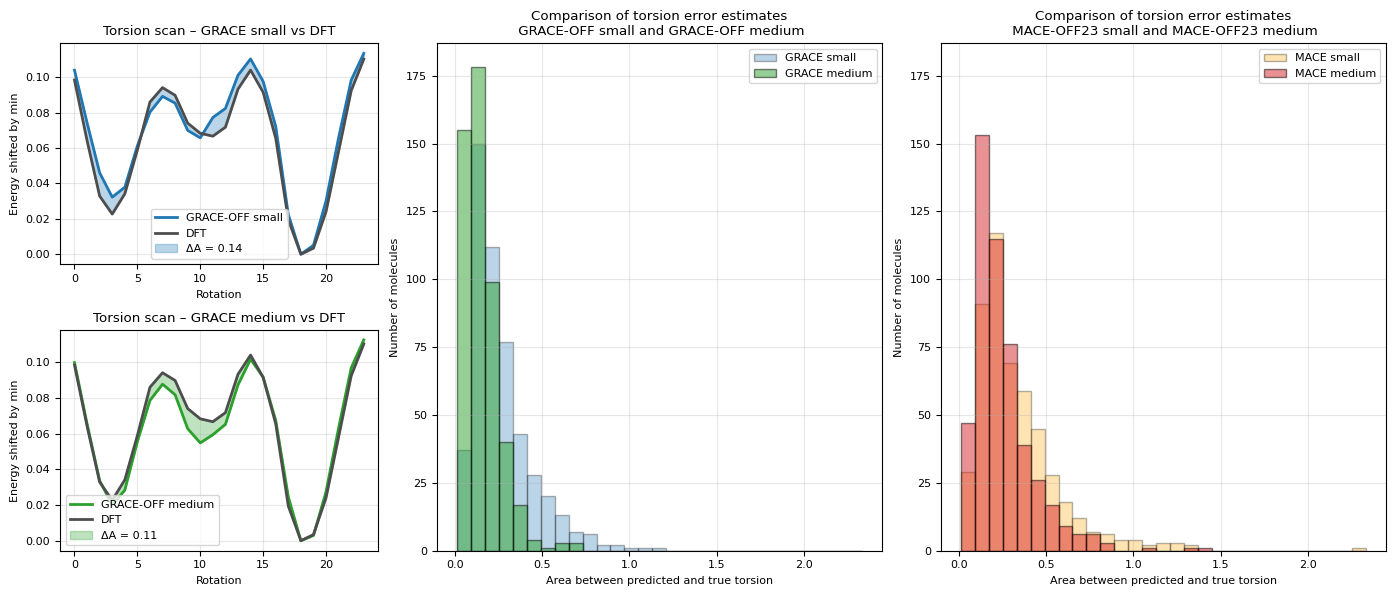

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Farben
color_small = "#1f77b4"   # Blau
color_medium = "#2ca02c"  # Grün
color_dft = "#4d4d4d"     # Dunkelgrau

# Daten vorbereiten
x = np.arange(len(torsion_energies_small))
torsion_small = np.asarray(torsion_energies_small) - np.min(np.asarray(torsion_energies_small))
torsion_med   = np.asarray(torsion_energies_medium) - np.min(np.asarray(torsion_energies_medium))
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = dft - np.min(dft)

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)



# Layout: 2 Zeilen, 2 Spalten, rechte Spalte breiter
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1.4, 1.4])

# --- Linke obere Hälfte: GRACE small vs DFT ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, torsion_small, color=color_small, label="GRACE-OFF small", linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.fill_between(x, torsion_small, dft, color=color_small, alpha=0.3, label=f"ΔA = {area_small:.2f}")
ax1.set_xlabel("Rotation")
ax1.set_ylabel("Energy shifted by min")
ax1.set_title("Torsion scan – GRACE small vs DFT")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Linke untere Hälfte: GRACE medium vs DFT ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, torsion_med, color=color_medium, label="GRACE-OFF medium", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  # gleiche Farbe wie oben
ax2.fill_between(x, torsion_med, dft, color=color_medium, alpha=0.3, label=f"ΔA = {area_medium:.2f}")
ax2.set_xlabel("Rotation")
ax2.set_ylabel("Energy shifted by min")
ax2.set_title("Torsion scan – GRACE medium vs DFT")
ax2.legend()
ax2.grid(True, alpha=0.3)


# Gemeinsame x-Achse für Histogramme
x_min = min(np.min(error_trapez_grace_small), np.min(error_trapez_grace_medium),
            np.min(error_trapez_mace_small), np.min(error_trapez_mace_medium))
x_max = max(np.max(error_trapez_grace_small), np.max(error_trapez_grace_medium),
            np.max(error_trapez_mace_small), np.max(error_trapez_mace_medium))

bar_width = 0.08  # Breite der Bars
bins = np.arange(x_min, x_max + bar_width, bar_width)  # Grenzen für alle Histogramme

# --- Rechte Seite (über beide Zeilen): Histogramm ---
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(error_trapez_grace_small, bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE small')
ax3.hist(error_trapez_grace_medium, bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE medium')
ax3.set_xlabel("Area between predicted and true torsion")
ax3.set_ylabel("Number of molecules")
ax3.set_title("Comparison of torsion error estimates\n GRACE-OFF small and GRACE-OFF medium")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[:, 2], sharex=ax3, sharey=ax3)
ax4.hist(error_trapez_mace_small, bins=bins, color='orange', edgecolor='black', alpha=0.3, label='MACE small')
ax4.hist(error_trapez_mace_medium, bins=bins, color='tab:red', edgecolor='black', alpha=0.5, label='MACE medium')
ax4.set_xlabel("Area between predicted and true torsion")
ax4.set_ylabel("Number of molecules")
ax4.set_title("Comparison of torsion error estimates\n MACE-OFF23 small and MACE-OFF23 medium")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [1]:
symbols = [chemical_symbols[int(z)] for z in Z]
dft_energies = data[key]["dft total energy"][:] * 27.211386245988
dft_energies = [e - min(dft_energies) for e in dft_energies]

NameError: name 'Z' is not defined

In [3]:
## Models to investigate
# MACE models for comparison
calc_mace_large = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_large.model", device="cuda"
)
calc_mace_medium = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF24_medium.model", device="cuda"
)
calc_mace_small = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_small.model", device="cuda"
)
# GRACE models
calc_grace_small = TPCalculator(
    model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/b_off_small/seed/1/saved_model/"
)
# calc_grace_medium = TPCalculator(
#     model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/b_off_medium/seed/1/saved_model/"
# )
# calc_grace_large = TPCalculator(
#     model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/2_layer/a_wpS_large/seed/1/saved_model/"
# )

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
I0000 00:00:1762248626.883916 1206178 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 932 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6


In [4]:
def calculate_energies_for_torsions(data):

    # diff_mace_large = []
    # diff_mace_medium = []
    # diff_mace_small = []
    diff_grace_small = []
    diff_grace_medium = []
    # diff_grace_large = []

    keys = list(data) 
    sample_keys = random.sample(keys, 5)

    for key in tqdm.tqdm(list(data.keys())):  # list(data.keys())

        Z = data[key]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]
        dft_energies = data[key]["dft total energy"][:] * 27.211386245988
        dft_energies = [e - min(dft_energies) for e in dft_energies]

        # energies_mace_large = []
        # energies_mace_medium = []
        # energies_mace_small = []
        energies_grace_small = []
        energies_grace_medium = []
        # energies_grace_large = []

        for i in range(len(data[key]["conformations"])):
            pos = data[key]["conformations"][i][:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            # mol.calc = calc_mae_large
            # e = mol.get_potential_energy()
            # energies_mace_large.append(e)

            # mol.calc = calc_mace_medium
            # e = mol.get_potential_energy()
            # energies_mace_medium.append(e)

            # mol.calc = calc_mace_small
            # e = mol.get_potential_energy()
            # energies_mace_small.append(e)

            mol.calc = calc_grace_small
            e = mol.get_potential_energy()
            energies_grace_small.append(e)

            mol.calc = calc_grace_medium
            e = mol.get_potential_energy()
            energies_grace_medium.append(e)

            # mol.calc = calc_grace_large
            # e = mol.get_potential_energy()
            # energies_grace_large.append(e)

        # energies_mace_large = [
        #     e - min(energies_mace_large) for e in energies_mace_large
        # ]
        # energies_mace_medium = [
        #     e - min(energies_mace_medium) for e in energies_mace_medium
        # ]
        # energies_mace_small = [
        #     e - min(energies_mace_small) for e in energies_mace_small
        # ]
        energies_grace_small = [
            e - min(energies_grace_small) for e in energies_grace_small
        ]
        energies_grace_medium = [
            e - min(energies_grace_medium) for e in energies_grace_medium
        ]
        # energies_grace_large = [
        #     e - min(energies_grace_large) for e in energies_grace_large
        # ]

        # diff_mace_large.append(
        #     np.mean(np.asarray(energies_mace_large) - np.asarray(dft_energies))
        # )
        # diff_mace_medium.append(
        #     np.mean(np.asarray(energies_mace_medium) - np.asarray(dft_energies))
        # )
        # diff_mace_small.append(
        #     np.mean(np.asarray(energies_mace_small) - np.asarray(dft_energies))
        # )
        diff_grace_small.append(
            np.mean(np.asarray(energies_grace_small) - np.asarray(dft_energies))
        )
        diff_grace_medium.append(
            np.mean(np.asarray(energies_grace_medium) - np.asarray(dft_energies))
        )
        # diff_grace_large.append(
        #     np.mean(np.asarray(energies_grace_large) - np.asarray(dft_energies))
        # )
        

    # print("MACE large modell:", round(np.mean(np.abs(diff_mace_large)), 3))
    # print("MACE medium modell:", round(np.mean(np.abs(diff_mace_medium)), 3))
    # print("MACE small modell:", round(np.mean(np.abs(diff_mace_small)), 3))
    print("Mod Grace modell:", round(np.mean(np.abs(diff_grace_small)), 3))
    print("Mod Grace medium modell:", round(np.mean(np.abs(diff_grace_medium)), 3))
    # print("Mod Grace large modell:", round(np.mean(np.abs(diff_grace_large)), 3))

    # Write results to CSV file
    results_df = pd.DataFrame(
        {
            "Model": [
                # "MACE large",
                # "MACE medium",
                # "MACE small",
                "GRACE small",
                "GRACE medium",
                # "GRACE large",
            ],
            "MAE_eV": [
                # np.mean(np.abs(diff_mace_large)),
                # np.mean(np.abs(diff_mace_medium)),
                # np.mean(np.abs(diff_mace_small)),
                np.mean(np.abs(diff_grace_small)),
                np.mean(np.abs(diff_grace_medium)),
                # np.mean(np.abs(diff_grace_large)),
            ],
        }
    )
    results_df.to_csv(f"{experiment}/torsion_energies_results_{data.filename.split('/')[-1].split('.')[0]}.csv", index=False)

    # plt.bar(
    #     ["MACE large", "MACE medium", "MACE small", "GRACE small", "GRACE medium"],
    #     [
    #         np.mean(np.abs(diff_mace_large)),
    #         np.mean(np.abs(diff_mace_medium)),
    #         np.mean(np.abs(diff_mace_small)),
    #         np.mean(np.abs(diff_grace_small)),
    #         np.mean(np.abs(diff_grace_medium)),
    #     ],
    # )
    # plt.ylabel("MAE [eV]")
    # # plt.yscale("log")
    # plt.show()

    return (
        # diff_mace_large,
        # diff_mace_medium,
        # diff_mace_small,
        diff_grace_small,
        diff_grace_medium,
        # diff_grace_large,
    )


def plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    # diff_grace_large,
    data,
):
    sns.set_theme(style="white")

    mae_vals = [
        np.mean(np.abs(diff_mace_large)),
        # np.mean(np.abs(diff_grace_large)),        
        np.mean(np.abs(diff_mace_medium)),
        np.mean(np.abs(diff_grace_medium)),
        np.mean(np.abs(diff_mace_small)),
        np.mean(np.abs(diff_grace_small)),  
    ]

    labels = [
        "MACE\nlarge",
        "GRACE\nlarge",
        "MACE\nmedium",
        "GRACE\nmedium",
        "MACE\nsmall",
        "GRACE\nsmall",
    ]
    families = ["MACE", "GRACE", "MACE", "GRACE", "MACE", "GRACE"]

    df = pd.DataFrame({"Model": labels, "MAE_eV": mae_vals, "Architecture": families})

    # Same color for all MACE bars and same for all GRACE bars
    palette = {
        "MACE": sns.color_palette("deep")[0],
        "GRACE": sns.color_palette("deep")[2],
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(
        data=df,
        x="Model",
        y="MAE_eV",
        hue="Architecture",
        dodge=False,
        palette=palette,
        ax=ax,
    )

    ax.set_ylabel("MAE [eV]")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), ha="center")

    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(f"{experiment}/torsion_energies_bar_chart_{data.filename.split('/')[-1].split('.')[0]}.png", dpi=300)
    plt.show()

100%|██████████| 500/500 [04:19<00:00,  1.92it/s]
/tmp/ipykernel_4064375/4237941545.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


Mod Grace modell: 0.017
Mod Grace medium modell: 0.014
Mod Grace large modell: 0.015


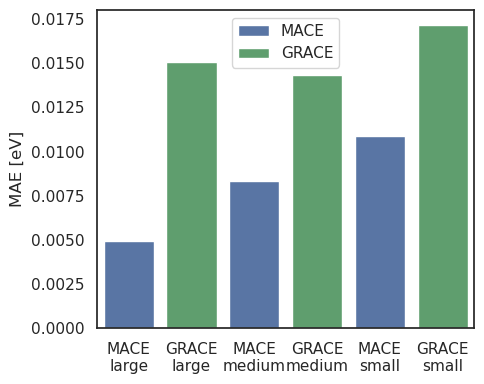

100%|██████████| 88/88 [00:46<00:00,  1.89it/s]
/tmp/ipykernel_4064375/4237941545.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


Mod Grace modell: 0.011
Mod Grace medium modell: 0.01
Mod Grace large modell: 0.009


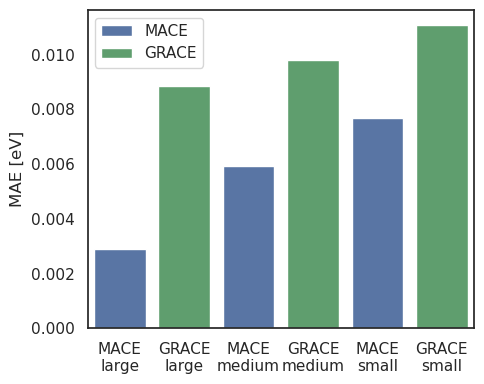

In [15]:
(
    # diff_mace_large,
    # diff_mace_medium,
    # diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
) = calculate_energies_for_torsions(data_tnet)

# Data for Tnet500
diff_mace_small = 0.010900202681683747
diff_mace_medium = 0.00832633049590034
diff_mace_large = 0.004945196822494154

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
    data_tnet,
)

(
    # diff_mace_large,
    # diff_mace_medium,
    # diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
) = calculate_energies_for_torsions(data_biaryl)

diff_mace_small = 0.007679090306856489
diff_mace_medium = 0.00591374014346839
diff_mace_large = 0.002914610214596471

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
    data_biaryl,
)

In [5]:
def calculate_energies_and_forces(calc, structures, ref_structures, model):

    pred_energies = []
    ref_energies = []
    pred_forces = []
    ref_forces = []

    for i, struc in enumerate(tqdm.tqdm(structures)):
        if model =="MACE":
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].info["total_energy"])

        else:
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].get_potential_energy())

        pred_forces.append(struc.get_forces().flatten())
        ref_forces.append(ref_structures[i].get_forces().flatten())

    return (
        pred_energies,
        ref_energies,
        pred_forces,
        ref_forces,
    )

In [ ]:
pred_energies_small, ref_energies_small, pred_forces_small, ref_forces_small = (
    calculate_energies_and_forces(calc_grace_small, structures, ref_structures, model="GRACE")
)
pred_energies_medium, ref_energies_medium, pred_forces_medium, ref_forces_medium = (
    calculate_energies_and_forces(calc_grace_medium, structures, ref_structures, model="GRACE")
)
pred_energies_large, ref_energies_large, pred_forces_large, ref_forces_large = (
    calculate_energies_and_forces(calc_grace_large, structures, ref_structures, model="GRACE")
)

In [6]:
pred_energies_small, ref_energies_small, pred_forces_small, ref_forces_small = (
    calculate_energies_and_forces(calc_mace_small, structures, ref_structures, model="MACE")
)
pred_energies_medium, ref_energies_medium, pred_forces_medium, ref_forces_medium = (
    calculate_energies_and_forces(calc_mace_medium, structures, ref_structures, model="MACE")
)
pred_energies_large, ref_energies_large, pred_forces_large, ref_forces_large = (
    calculate_energies_and_forces(calc_mace_large, structures, ref_structures, model="MACE")
)

  1%|          | 52/10000 [00:03<10:52, 15.24it/s]


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__/torch/fx/graph_module/___torch_mangle_11.py", line 130, in forward
    _w3j_2_3_1 = self._w3j_2_3_1
    mul_4 = torch.mul(_w3j_2_3_1, 1.7320508075688772)
    tensordot_2 = _0(einsum_17, mul_4, ([4, 3], [1, 0]), None, )
                  ~~ <--- HERE
    einsum_18 = torch.einsum("dbca,dbc->dba", [tensordot_2, reshape_28])
    reshape_29 = torch.reshape(einsum_18, [getitem_4, 672])
  File "code/__torch__/torch/functional/___torch_mangle_0.py", line 9, in tensordot
  dims_a, dims_b, = dims1
  if torch.__is__(out, None):
    _1 = torch.tensordot(a, b, dims_a, dims_b)
         ~~~~~~~~~~~~~~~ <--- HERE
    _0 = _1
  else:

Traceback of TorchScript, original code (most recent call last):
  File "<eval_with_key>.157", line 99, in forward
    _w3j_2_3_1 = self._w3j_2_3_1
    mul_4 = _w3j_2_3_1 * 1.7320508075688772;  _w3j_2_3_1 = 

NameError: name 'ref_energies_large' is not defined

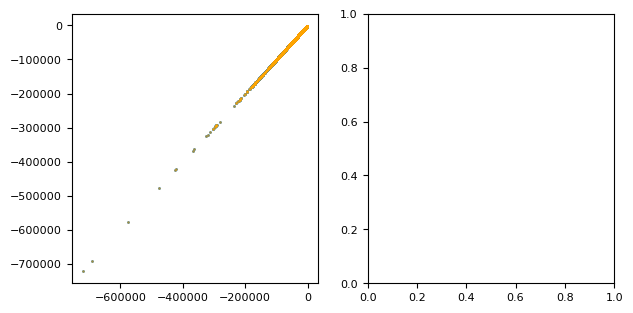

In [7]:
# Create subplot with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5))

# Energy plot (left subplot)
ax1.scatter(ref_energies_small, pred_energies_small, s=1)
ax1.scatter(
    ref_energies_medium,
    pred_energies_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
)
ax1.scatter(
    ref_energies_large,
    pred_energies_large,
    s=1,
    alpha=0.5,
    color="green",
    marker="^",
)

# Calculate R² score
r2_small = r2_score(ref_energies_small, pred_energies_small)
r2_medium = r2_score(ref_energies_medium, pred_energies_medium)
r2_large = r2_score(ref_energies_large, pred_energies_large)

# Add text box with R² score
ax1.text(
    0.05,
    0.95,
    f"R²(s) = {r2_small:.7f}\nR²(m) = {r2_medium:.7f}\nR²(l) = {r2_large:.7f}",
    transform=ax1.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_energies_small), min(pred_energies_small))
max_val = max(max(ref_energies_small), max(pred_energies_small))
ax1.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax1.set_xlabel("Reference Energies [eV]")
ax1.set_ylabel("Predicted Energies [eV]")
ax1.set_title("Energy Predictions")

print("Energies (s):", r2_small)
print("Energies (m):", r2_medium)
print("Energies (l):", r2_large)

# Forces plot (right subplot)
ref_forces_flat_small = np.concatenate(ref_forces_small).astype(float).tolist()
pred_forces_flat_small = np.concatenate(pred_forces_small).astype(float).tolist()

ref_forces_flat_medium = np.concatenate(ref_forces_medium).astype(float).tolist()
pred_forces_flat_medium = np.concatenate(pred_forces_medium).astype(float).tolist()

ref_forces_flat_large = np.concatenate(ref_forces_large).astype(float).tolist()
pred_forces_flat_large = np.concatenate(pred_forces_large).astype(float).tolist()

ax2.scatter(ref_forces_flat_small, pred_forces_flat_small, s=1, label="small")
ax2.scatter(
    ref_forces_flat_medium,
    pred_forces_flat_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
    label="medium",
)
ax2.scatter(
    ref_forces_flat_large,
    pred_forces_flat_large,
    s=1,
    alpha=0.5,
    color="green",
    marker="^",
    label="large",
)

# Calculate R² score for forces
r2_forces_small = r2_score(ref_forces_flat_small, pred_forces_flat_small)
r2_forces_medium = r2_score(ref_forces_flat_medium, pred_forces_flat_medium)
r2_forces_large = r2_score(ref_forces_flat_large, pred_forces_flat_large)

# Add text box with R² score
ax2.text(
    0.05,
    0.95,
    f"R²(s) = {r2_forces_small:.4f}\nR²(m) = {r2_forces_medium:.4f}\nR²(l) = {r2_forces_large:.4f}",
    transform=ax2.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_forces_flat_small), min(pred_forces_flat_small))
max_val = max(max(ref_forces_flat_small), max(pred_forces_flat_small))
ax2.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax2.set_xlabel("Reference Forces [eV/Å]")
ax2.set_ylabel("Predicted Forces [eV/Å]")
ax2.legend(loc="lower right")
ax2.set_title("Force Predictions")

print("Forces (s):", r2_forces_small)
print("Forces (m):", r2_forces_medium)
print("Forces (l):", r2_forces_large)

plt.tight_layout()
plt.savefig(f"{experiment}/energies_forces_scatter.png", dpi=300)
plt.show()

In [8]:
# Calculate MSE and RMSE for energies
mse_small_energy = mean_squared_error(ref_energies_small, pred_energies_small)
rmse_small_energy = root_mean_squared_error(ref_energies_small, pred_energies_small)
mse_medium_energy = mean_squared_error(ref_energies_medium, pred_energies_medium)
rmse_medium_energy = root_mean_squared_error(ref_energies_medium, pred_energies_medium)
mse_large_energy = mean_squared_error(ref_energies_large, pred_energies_large)
rmse_large_energy = root_mean_squared_error(ref_energies_large, pred_energies_large)
# Calculate MSE und RMSE for forces
mse_small_forces = mean_squared_error(ref_forces_flat_small, pred_forces_flat_small)
rmse_small_forces = root_mean_squared_error(
    ref_forces_flat_small, pred_forces_flat_small
)
mse_medium_forces = mean_squared_error(ref_forces_flat_medium, pred_forces_flat_medium)
rmse_medium_forces = root_mean_squared_error(
    ref_forces_flat_medium, pred_forces_flat_medium
)
mse_large_forces = mean_squared_error(ref_forces_flat_large, pred_forces_flat_large)
rmse_large_forces = root_mean_squared_error(
    ref_forces_flat_large, pred_forces_flat_large
)
# Print results
print("Energies")
print("Small model - MSE energy:", round(mse_small_energy, 4))
print("Medium model - MSE energy:", round(mse_medium_energy, 4))
print("Large model - MSE energy:", round(mse_large_energy, 4))
print("Small model - RMSE energy:", round(rmse_small_energy, 4))
print("Medium model - RMSE energy:", round(rmse_medium_energy, 4))
print("Large model - RMSE energy:", round(rmse_large_energy, 4))
print("Forces")
print("Small model - MSE forces:", round(mse_small_forces, 4))
print("Medium model - MSE forces:", round(mse_medium_forces, 4))
print("Large model - MSE forces:", round(mse_large_forces, 4))
print("Small model - RMSE forces:", round(rmse_small_forces, 4))
print("Medium model - RMSE forces:", round(rmse_medium_forces, 4))
print("Large model - RMSE forces:", round(rmse_large_forces, 4))

# Write results to CSV file
metrics_df = pd.DataFrame(
    {
        "Model": ["GRACE small", "GRACE medium", "GRACE large"],
        "MSE_Energy": [mse_small_energy, mse_medium_energy, mse_large_energy],
        "RMSE_Energy": [rmse_small_energy, rmse_medium_energy, rmse_large_energy],
        "MSE_Forces": [mse_small_forces, mse_medium_forces, mse_large_forces],
        "RMSE_Forces": [rmse_small_forces, rmse_medium_forces, rmse_large_forces],
    }
)
metrics_df.to_csv(f"{experiment}/energy_force_metrics.csv", index=False)

NameError: name 'ref_energies_large' is not defined

In [16]:
n_atoms_list = []
per_atom_energy_errors_small = []
per_atom_energy_errors_medium = []
per_atom_energy_errors_large = []

for i, struc in enumerate(tqdm.tqdm(structures)):
    try:
        n = len(struc)
        n_atoms_list.append(n)

        per_atom_energy_errors_small.append(
            abs(ref_energies_small[i] - pred_energies_small[i]) / n
        )
        per_atom_energy_errors_medium.append(
            abs(ref_energies_medium[i] - pred_energies_medium[i]) / n
        )
        per_atom_energy_errors_large.append(
            abs(ref_energies_large[i] - pred_energies_large[i]) / n
        )
    except:
        continue

print("Per Atom error (small) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000)
print("Per Atom error (medium) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000)
print("Per Atom error (large) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_large) ** 2)) * 1000)

# Save per-atom error results to CSV
per_atom_rmse_small = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000
per_atom_rmse_medium = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000
per_atom_rmse_large = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_large) ** 2)) * 1000

per_atom_df = pd.DataFrame({
    "Model": ["GRACE small", "GRACE medium", "GRACE large"],
    "Per_Atom_RMSE_meV": [per_atom_rmse_small, per_atom_rmse_medium, per_atom_rmse_large]
})
per_atom_df.to_csv(f"{experiment}/per_atom_energy_errors.csv", index=False)

100%|██████████| 10000/10000 [00:00<00:00, 340939.34it/s]

Per Atom error (small) in meV:  15.32873267226503
Per Atom error (medium) in meV:  16.310999477370487
Per Atom error (large) in meV:  16.268882118596547
